**Diabetes Disease**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import  GradientBoostingClassifier
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import warnings
warnings.simplefilter(action='ignore')
sns.set()
plt.style.use("ggplot")
%matplotlib inline


In [3]:
diabetes_df = pd.read_csv("C:/Users/sneha/major project/Disease Dataset/diabetes_5000.csv")
print(diabetes_df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            9      102             76             37        0  32.9   
1            4      171             72              0        0  43.6   
2           13      126             90              0        0  43.4   
3            1       93             70             31        0  30.4   
4            7      187             50             33      392  33.9   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.665   46        1  
1                     0.479   26        1  
2                     0.583   42        1  
3                     0.315   23        0  
4                     0.826   34        1  


In [5]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               5000 non-null   int64  
 1   Glucose                   5000 non-null   int64  
 2   BloodPressure             5000 non-null   int64  
 3   SkinThickness             5000 non-null   int64  
 4   Insulin                   5000 non-null   int64  
 5   BMI                       5000 non-null   float64
 6   DiabetesPedigreeFunction  5000 non-null   float64
 7   Age                       5000 non-null   int64  
 8   Outcome                   5000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 351.7 KB


In [7]:
diabetes_df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [9]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.809200,120.939400,69.092200,20.665400,78.699000,32.084340,0.468942,32.849600,0.353600
std,3.371093,31.635124,19.195734,15.808574,110.763975,7.611248,0.326951,11.326016,0.478135
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.400000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,70.000000,23.000000,37.000000,32.100000,0.370000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,126.000000,36.600000,0.620250,40.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
# (row, columns)
diabetes_df.shape

(5000, 9)

In [13]:
# distribution of outcome variable
outcome_distribution = diabetes_df.Outcome.value_counts() * 100 / len(diabetes_df)
print(outcome_distribution)

Outcome
0    64.64
1    35.36
Name: count, dtype: float64


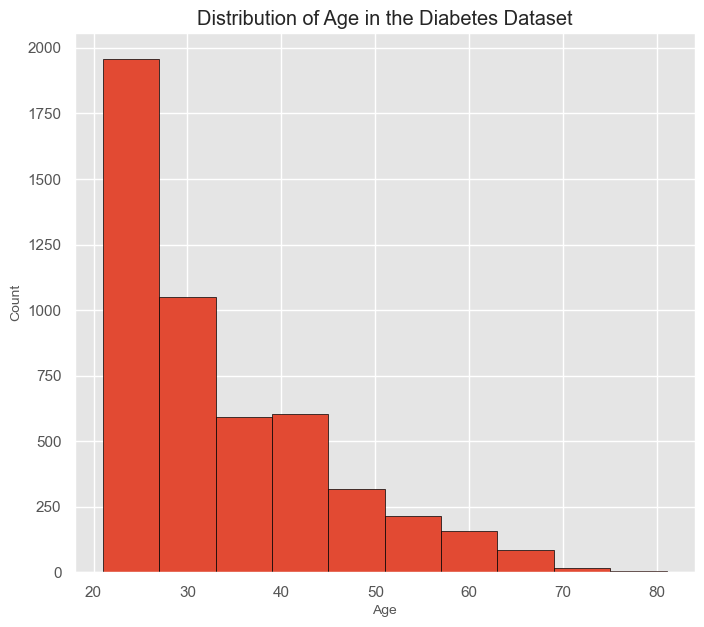

In [15]:
plt.figure(figsize=(8,7))
plt.xlabel('Age', fontsize=10)
plt.ylabel('Count', fontsize=10)
diabetes_df['Age'].hist(edgecolor="black")
plt.title('Distribution of Age in the Diabetes Dataset')
plt.show()

In [17]:
diabetes_df['Age'].max()

81

In [19]:
diabetes_df['Age'].min()

21

In [21]:
print("MAX AGE: "+str(diabetes_df['Age'].max()))
print("MIN AGE: "+str(diabetes_df['Age'].min()))

MAX AGE: 81
MIN AGE: 21


In [23]:
diabetes_df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

<Axes: xlabel='BMI', ylabel='Density'>

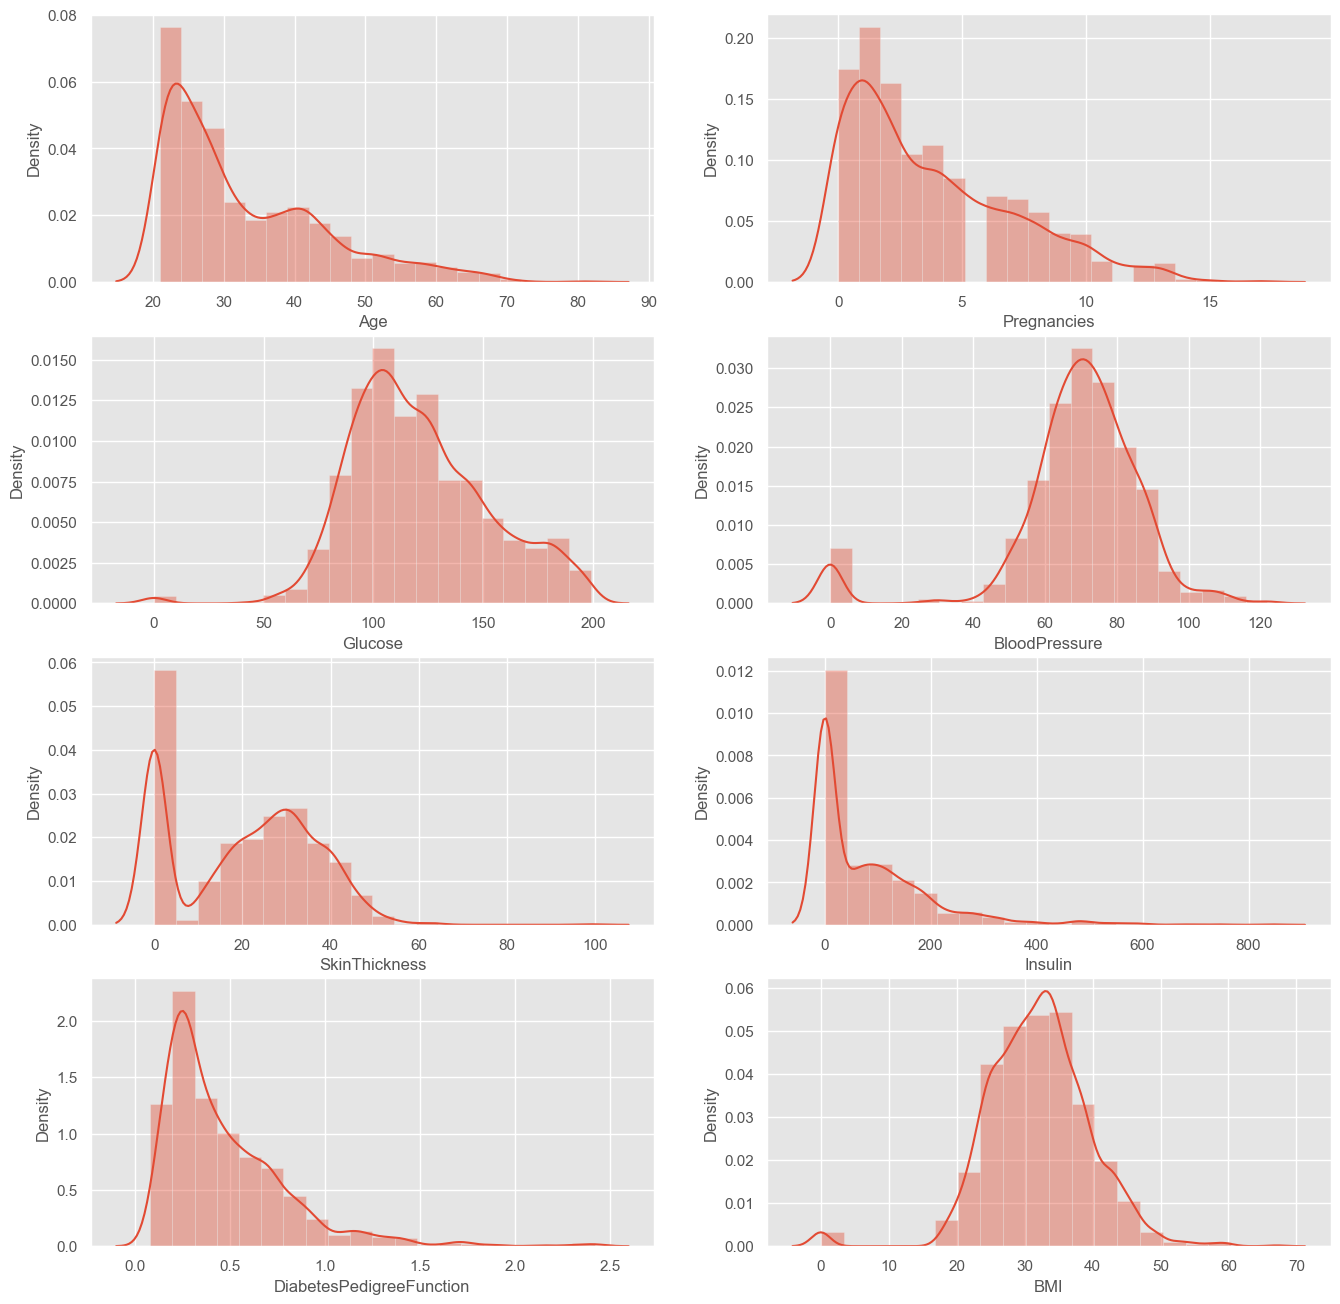

In [25]:
# Histogram and density graphs of all variables were accessed.
fig, ax = plt.subplots(4,2, figsize=(16,16))
sns.distplot(diabetes_df.Age, bins = 20, ax=ax[0,0]) 
sns.distplot(diabetes_df.Pregnancies, bins = 20, ax=ax[0,1]) 
sns.distplot(diabetes_df.Glucose, bins = 20, ax=ax[1,0]) 
sns.distplot(diabetes_df.BloodPressure, bins = 20, ax=ax[1,1]) 
sns.distplot(diabetes_df.SkinThickness, bins = 20, ax=ax[2,0])
sns.distplot(diabetes_df.Insulin, bins = 20, ax=ax[2,1])
sns.distplot(diabetes_df.DiabetesPedigreeFunction, bins = 20, ax=ax[3,0]) 
sns.distplot(diabetes_df.BMI, bins = 20, ax=ax[3,1]) 

In [27]:
diabetes_df.groupby("Outcome").agg({"Age":"mean"})

,Age
Outcome,
0,30.800743
1,36.595023


In [29]:
diabetes_df.groupby("Outcome").agg({"Age":"max"})

,Age
Outcome,
0,81
1,70


In [31]:
diabetes_df.groupby("Outcome").agg({"Insulin": "mean"})

,Insulin
Outcome,
0,65.813428
1,102.254525


In [33]:
diabetes_df.groupby("Outcome").agg({"Insulin": "max"})

,Insulin
Outcome,
0,744
1,846


In [35]:
diabetes_df.groupby("Outcome").agg({"Glucose": "mean"})

,Glucose
Outcome,
0,109.308478
1,142.201357


In [37]:
diabetes_df.groupby("Outcome").agg({"Glucose": "max"})

,Glucose
Outcome,
0,197
1,199


In [39]:
diabetes_df.groupby("Outcome").agg({"BMI": "mean"})

,BMI
Outcome,
0,30.458756
1,35.055995


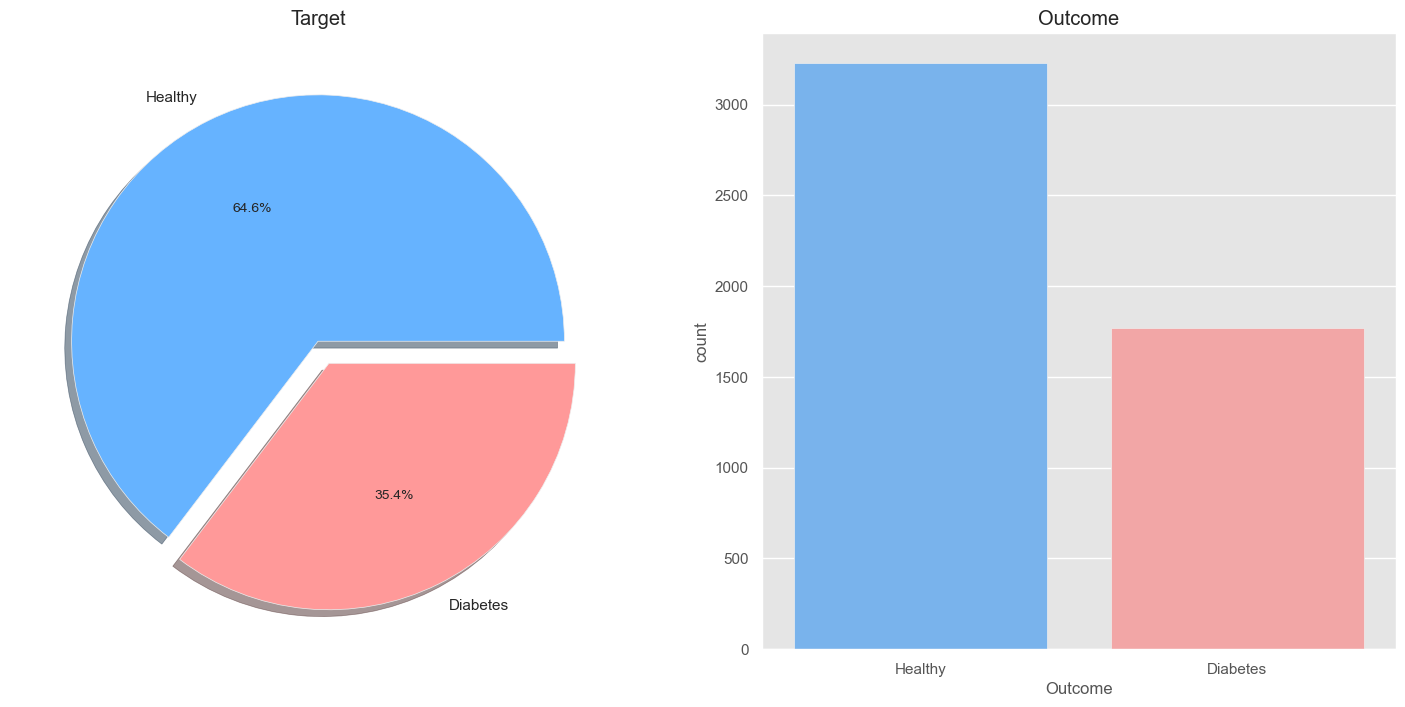

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create subplots
f, ax = plt.subplots(1, 2, figsize=(18, 8))

# Plot pie chart for Outcome distribution
diabetes_df['Outcome'].value_counts().plot.pie(explode=[0, 0.1], autopct="%1.1f%%", ax=ax[0], shadow=True, labels=['Healthy', 'Diabetes'], colors=['#66b3ff', '#ff9999'])
ax[0].set_title('Target')
ax[0].set_ylabel('')  # Remove y-axis label

# Plot count plot for Outcome
sns.countplot(x='Outcome', data=diabetes_df, ax=ax[1], palette=['#66b3ff', '#ff9999'])
ax[1].set_title('Outcome')
ax[1].set_xticklabels(['Healthy', 'Diabetes'])  # Set custom labels for x-axis

# Show plot
plt.show()


In [43]:
diabetes_df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.122377,0.144778,-0.092160,-0.086151,0.026988,-0.044242,0.552581,0.212512
Glucose,0.122377,1.000000,0.157517,0.066359,0.330525,0.238027,0.143923,0.248518,0.497144
BloodPressure,0.144778,0.157517,1.000000,0.195300,0.072269,0.271593,0.032940,0.255533,0.071510
SkinThickness,-0.092160,0.066359,0.195300,1.000000,0.433567,0.384026,0.179263,-0.123475,0.077955
Insulin,-0.086151,0.330525,0.072269,0.433567,1.000000,0.172363,0.186816,-0.060817,0.157305
BMI,0.026988,0.238027,0.271593,0.384026,0.172363,1.000000,0.136497,0.041166,0.288796
DiabetesPedigreeFunction,-0.044242,0.143923,0.032940,0.179263,0.186816,0.136497,1.000000,0.034169,0.188804
Age,0.552581,0.248518,0.255533,-0.123475,-0.060817,0.041166,0.034169,1.000000,0.244609
Outcome,0.212512,0.497144,0.071510,0.077955,0.157305,0.288796,0.188804,0.244609,1.000000


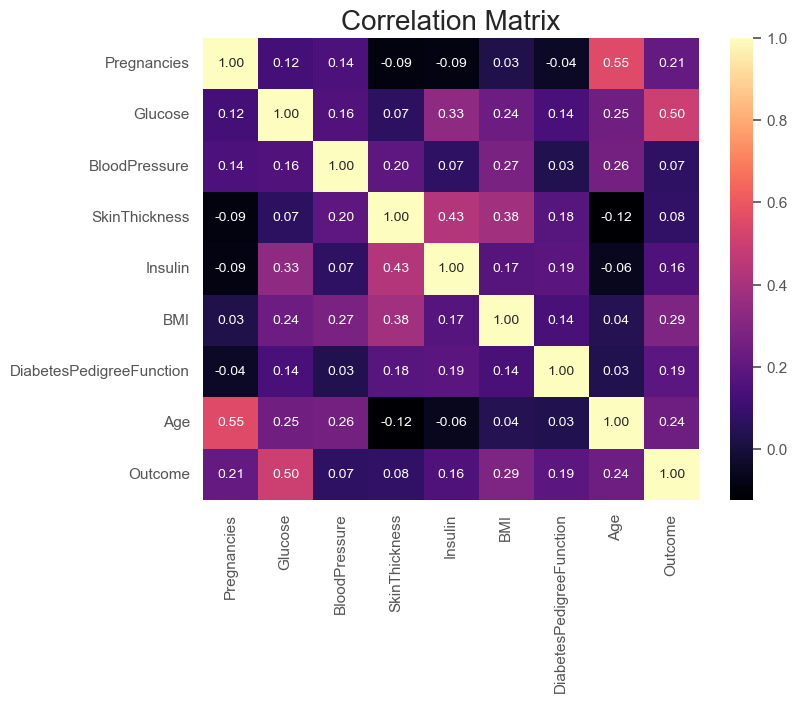

In [45]:
# Correlation matrix graph of the data set
f, ax = plt.subplots(figsize= [8,6])
sns.heatmap(diabetes_df.corr(), annot=True, fmt=".2f", ax=ax, cmap = "magma" )
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

**Data preprocessing Part**

In [47]:
diabetes_df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = diabetes_df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)

In [49]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,9,102.0,76.0,37.0,NaN,32.9,0.665,46,1
1,4,171.0,72.0,NaN,NaN,43.6,0.479,26,1
2,13,126.0,90.0,NaN,NaN,43.4,0.583,42,1
3,1,93.0,70.0,31.0,NaN,30.4,0.315,23,0
4,7,187.0,50.0,33.0,392.0,33.9,0.826,34,1


In [51]:
# Now, we can look at where are missing values
diabetes_df.isnull().sum()

Pregnancies                    0
Glucose                       24
BloodPressure                217
SkinThickness               1444
Insulin                     2411
BMI                           56
DiabetesPedigreeFunction       0
Age                            0
Outcome                        0
dtype: int64

In [53]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,9,102.0,76.0,37.0,NaN,32.9,0.665,46,1
1,4,171.0,72.0,NaN,NaN,43.6,0.479,26,1
2,13,126.0,90.0,NaN,NaN,43.4,0.583,42,1
3,1,93.0,70.0,31.0,NaN,30.4,0.315,23,0
4,7,187.0,50.0,33.0,392.0,33.9,0.826,34,1


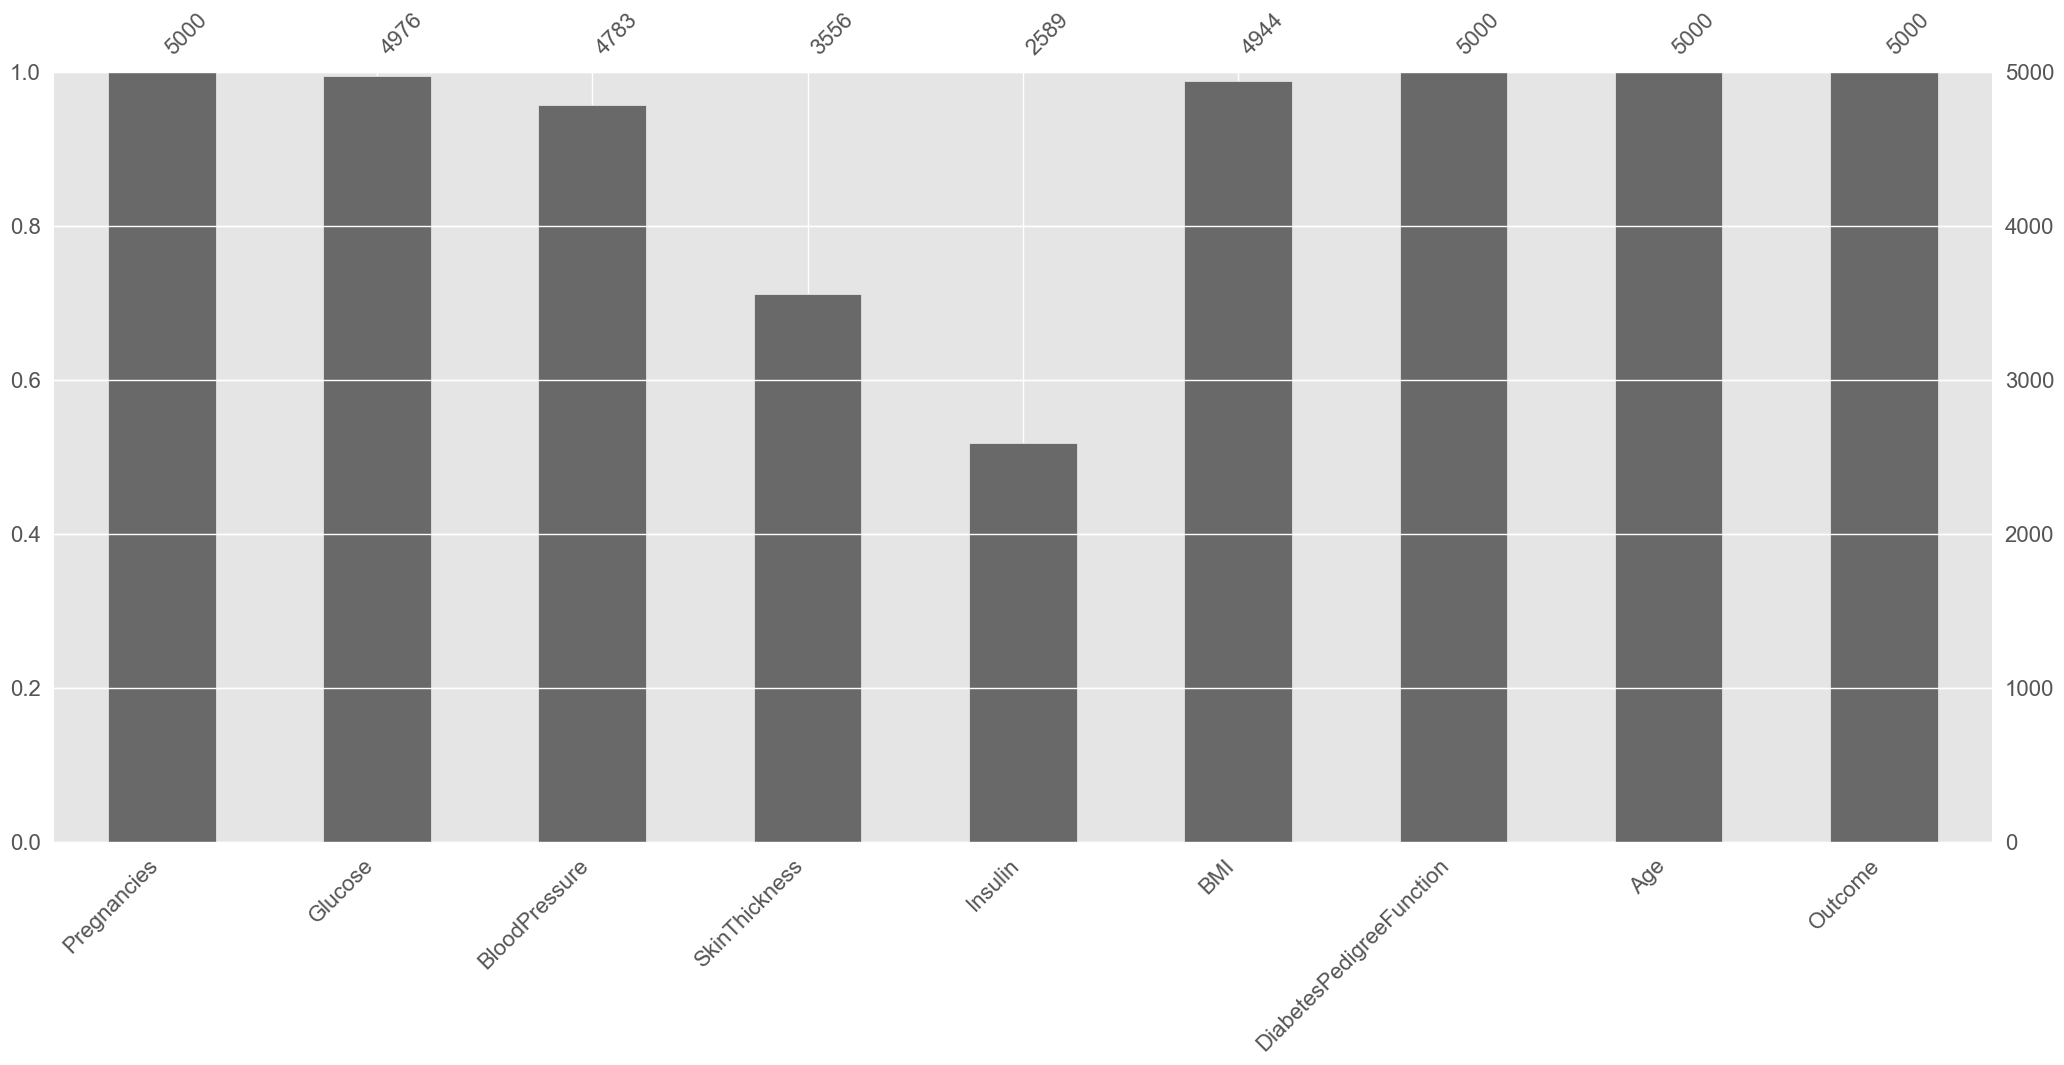

In [55]:
# Have been visualized using the missingno library for the visualization of missing observations.
# Plotting 
import missingno as msno
msno.bar(diabetes_df);

In [57]:
# The missing values ​​will be filled with the median values ​​of each variable.
def median_target(var):   
    temp = diabetes_df[diabetes_df[var].notnull()]
    temp = temp[[var, 'Outcome']].groupby(['Outcome'])[[var]].median().reset_index()
    return temp

In [59]:
# The values to be given for incomplete observations are given the median value of people who are not sick and the median values of people who are sick.
columns = diabetes_df.columns
columns = columns.drop("Outcome")
for i in columns:
    median_target(i)
    diabetes_df.loc[(diabetes_df['Outcome'] == 0 ) & (diabetes_df[i].isnull()), i] = median_target(i)[i][0]
    diabetes_df.loc[(diabetes_df['Outcome'] == 1 ) & (diabetes_df[i].isnull()), i] = median_target(i)[i][1]

In [61]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,9,102.0,76.0,37.0,168.0,32.9,0.665,46,1
1,4,171.0,72.0,32.0,168.0,43.6,0.479,26,1
2,13,126.0,90.0,32.0,168.0,43.4,0.583,42,1
3,1,93.0,70.0,31.0,100.0,30.4,0.315,23,0
4,7,187.0,50.0,33.0,392.0,33.9,0.826,34,1


In [63]:
# Missing values were filled.
diabetes_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

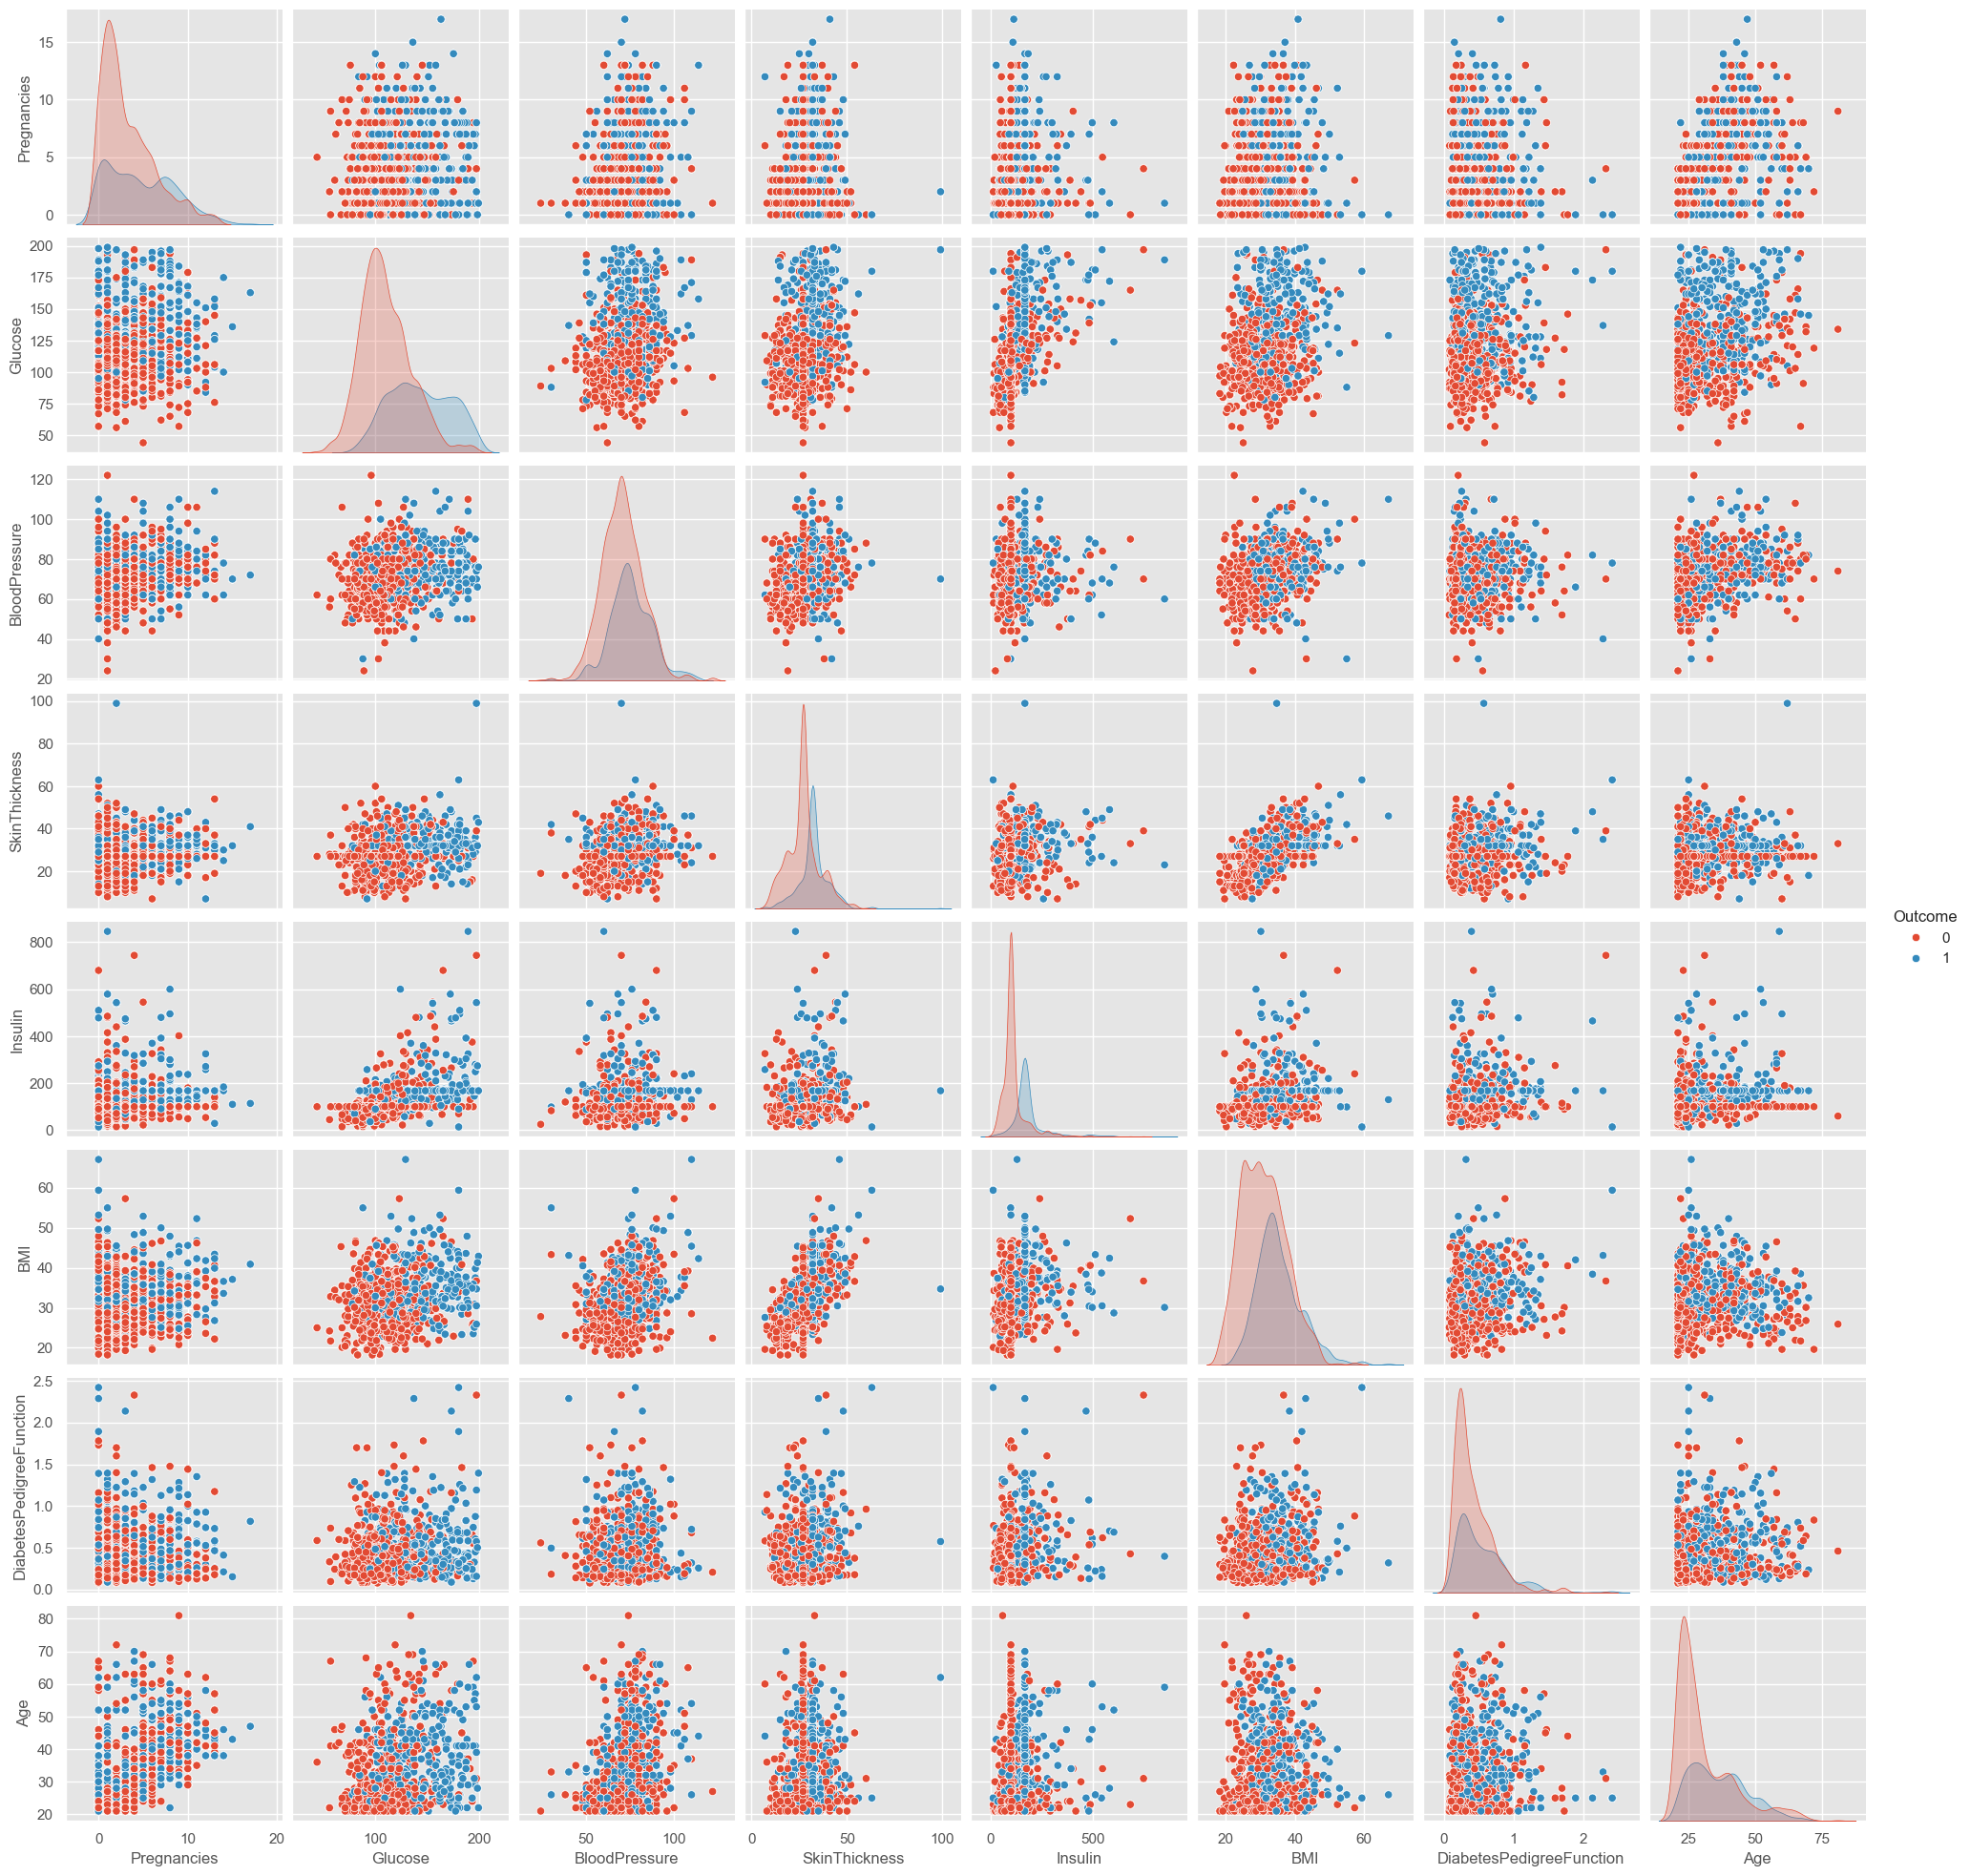

In [65]:
# pair plot
p = sns.pairplot(diabetes_df, hue="Outcome")

**Outlier Observation Analysis**

In [67]:
# In the data set, there were asked whether there were any outlier observations compared to the 25% and 75% quarters.
# It was found to be an outlier observation.
for feature in diabetes_df:
    
    Q1 = diabetes_df[feature].quantile(0.25)
    Q3 = diabetes_df[feature].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1- 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    if diabetes_df[(diabetes_df[feature] > upper)].any(axis=None):
        print(feature,"yes")
    else:
        print(feature, "no")

Pregnancies yes
Glucose no
BloodPressure yes
SkinThickness yes
Insulin yes
BMI yes
DiabetesPedigreeFunction yes
Age yes
Outcome no


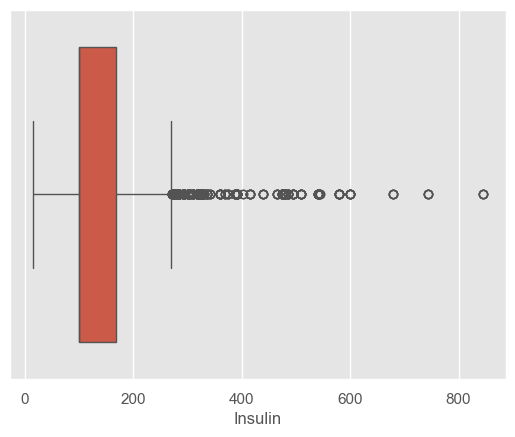

In [69]:
# The process of visualizing the Insulin variable with boxplot method was done. We find the outlier observations on the chart.
import seaborn as sns
sns.boxplot(x = diabetes_df["Insulin"]);

In [71]:
#We conduct a stand alone observation review for the Insulin variable
#We suppress contradictory values
Q1 = diabetes_df.Insulin.quantile(0.25)
Q3 = diabetes_df.Insulin.quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
diabetes_df.loc[diabetes_df["Insulin"] > upper,"Insulin"] = upper

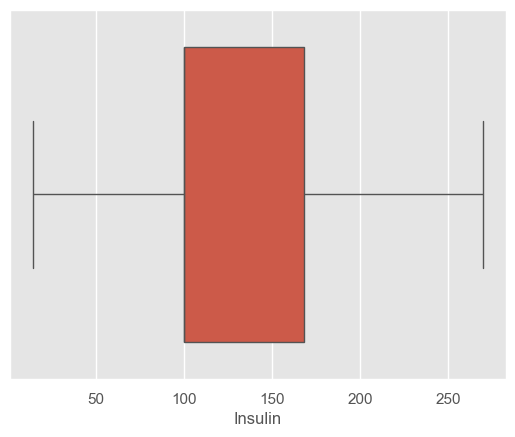

In [73]:
import seaborn as sns
sns.boxplot(x = diabetes_df["Insulin"]);

In [75]:
# LOF
# local outlier factor
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=10)
lof.fit_predict(diabetes_df)

array([1, 1, 1, ..., 1, 1, 1])

In [77]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,9,102.0,76.0,37.0,168.0,32.9,0.665,46,1
1,4,171.0,72.0,32.0,168.0,43.6,0.479,26,1
2,13,126.0,90.0,32.0,168.0,43.4,0.583,42,1
3,1,93.0,70.0,31.0,100.0,30.4,0.315,23,0
4,7,187.0,50.0,33.0,270.0,33.9,0.826,34,1


<Axes: xlabel='Pregnancies'>

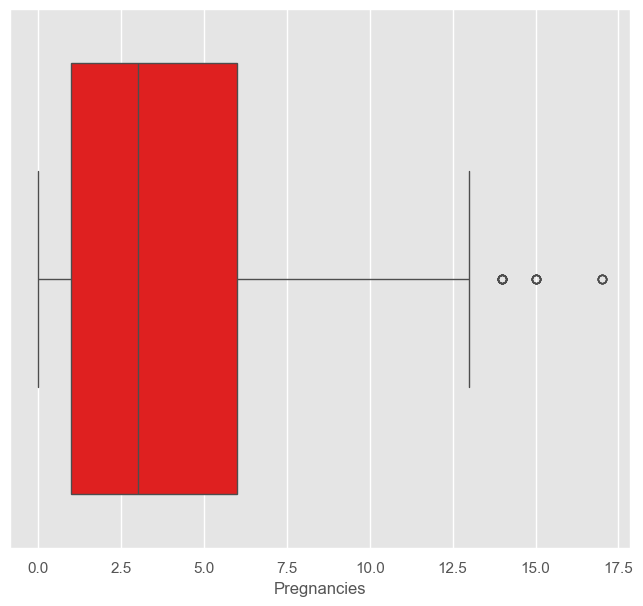

In [79]:
plt.figure(figsize=(8,7))
sns.boxplot(x= diabetes_df["Pregnancies"], color="red")

In [81]:
df_scores = lof.negative_outlier_factor_
np.sort(df_scores)[0:30]

array([-1.65606150e+11, -1.65606150e+11, -1.65606150e+11, -1.65606150e+11,
       -1.65606150e+11, -1.65606150e+11, -1.60547292e+11, -1.60547292e+11,
       -1.60547292e+11, -1.60547292e+11, -1.48522899e+11, -1.48522899e+11,
       -1.48522899e+11, -1.48522899e+11, -1.48522899e+11, -1.48522899e+11,
       -1.48522899e+11, -1.33252589e+11, -1.33252589e+11, -1.33252589e+11,
       -1.32443858e+11, -1.32443858e+11, -1.32443858e+11, -1.32443858e+11,
       -1.32443858e+11, -1.32443858e+11, -1.30832528e+11, -1.30832528e+11,
       -1.30832528e+11, -1.30832528e+11])

In [83]:
thresold = np.sort(df_scores)[7]

In [85]:
thresold

-160547291504.15802

In [87]:
outlier = df_scores>thresold

In [89]:
diabetes_df = diabetes_df[outlier]

In [91]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,9,102.0,76.0,37.0,168.0,32.9,0.665,46,1
1,4,171.0,72.0,32.0,168.0,43.6,0.479,26,1
2,13,126.0,90.0,32.0,168.0,43.4,0.583,42,1
3,1,93.0,70.0,31.0,100.0,30.4,0.315,23,0
4,7,187.0,50.0,33.0,270.0,33.9,0.826,34,1


<Axes: xlabel='Pregnancies'>

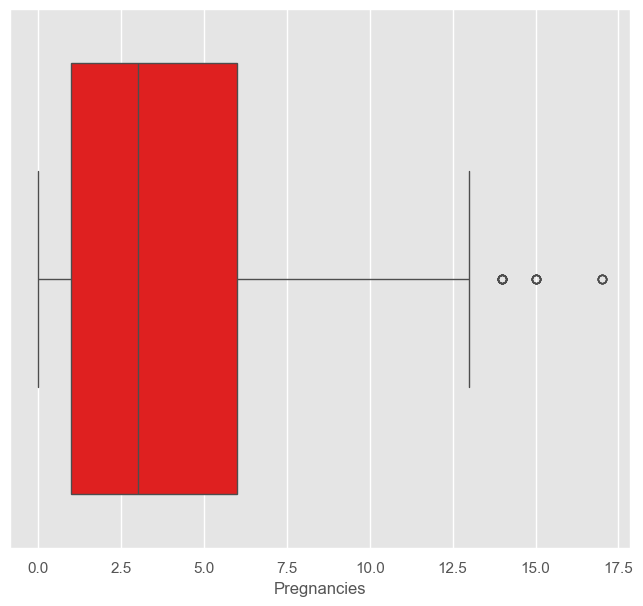

In [93]:
plt.figure(figsize=(8,7))
sns.boxplot(x= diabetes_df["Pregnancies"], color="red")

**Feature Engineering**

In [95]:
# Feature Enginnering
NewBMI = pd.Series(["Underweight","Normal", "Overweight","Obesity 1", "Obesity 2", "Obesity 3"], dtype = "category")

In [97]:
NewBMI

0    Underweight
1         Normal
2     Overweight
3      Obesity 1
4      Obesity 2
5      Obesity 3
dtype: category
Categories (6, object): ['Normal', 'Obesity 1', 'Obesity 2', 'Obesity 3', 'Overweight', 'Underweight']

In [99]:
# According to BMI, some ranges were determined and categorical variables were assigned.
NewBMI = pd.Series(["Underweight", "Normal", "Overweight", "Obesity 1", "Obesity 2", "Obesity 3"], dtype = "category")
diabetes_df["NewBMI"] = NewBMI
diabetes_df.loc[diabetes_df["BMI"] < 18.5, "NewBMI"] = NewBMI[0]
diabetes_df.loc[(diabetes_df["BMI"] > 18.5) & (diabetes_df["BMI"] <= 24.9), "NewBMI"] = NewBMI[1]
diabetes_df.loc[(diabetes_df["BMI"] > 24.9) & (diabetes_df["BMI"] <= 29.9), "NewBMI"] = NewBMI[2]
diabetes_df.loc[(diabetes_df["BMI"] > 29.9) & (diabetes_df["BMI"] <= 34.9), "NewBMI"] = NewBMI[3]
diabetes_df.loc[(diabetes_df["BMI"] > 34.9) & (diabetes_df["BMI"] <= 39.9), "NewBMI"] = NewBMI[4]
diabetes_df.loc[diabetes_df["BMI"] > 39.9 ,"NewBMI"] = NewBMI[5]

In [101]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI
0,9,102.0,76.0,37.0,168.0,32.9,0.665,46,1,Obesity 1
1,4,171.0,72.0,32.0,168.0,43.6,0.479,26,1,Obesity 3
2,13,126.0,90.0,32.0,168.0,43.4,0.583,42,1,Obesity 3
3,1,93.0,70.0,31.0,100.0,30.4,0.315,23,0,Obesity 1
4,7,187.0,50.0,33.0,270.0,33.9,0.826,34,1,Obesity 1


In [103]:
# if insulin>=16 & insuline<=166->normal
def set_insuline(row):
    if row["Insulin"]>=16 and row["Insulin"]<=166:
        return "Normal"
    else:
        return "Abnormal"

In [105]:
diabetes_df = diabetes_df.assign(NewInsulinScore=diabetes_df.apply(set_insuline, axis=1))

In [107]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI,NewInsulinScore
0,9,102.0,76.0,37.0,168.0,32.9,0.665,46,1,Obesity 1,Abnormal
1,4,171.0,72.0,32.0,168.0,43.6,0.479,26,1,Obesity 3,Abnormal
2,13,126.0,90.0,32.0,168.0,43.4,0.583,42,1,Obesity 3,Abnormal
3,1,93.0,70.0,31.0,100.0,30.4,0.315,23,0,Obesity 1,Normal
4,7,187.0,50.0,33.0,270.0,33.9,0.826,34,1,Obesity 1,Abnormal


In [109]:
# Some intervals were determined according to the glucose variable and these were assigned categorical variables.
NewGlucose = pd.Series(["Low", "Normal", "Overweight", "Secret", "High"], dtype = "category")
diabetes_df["NewGlucose"] = NewGlucose
diabetes_df.loc[diabetes_df["Glucose"] <= 70, "NewGlucose"] = NewGlucose[0]
diabetes_df.loc[(diabetes_df["Glucose"] > 70) & (diabetes_df["Glucose"] <= 99), "NewGlucose"] = NewGlucose[1]
diabetes_df.loc[(diabetes_df["Glucose"] > 99) & (diabetes_df["Glucose"] <= 126), "NewGlucose"] = NewGlucose[2]
diabetes_df.loc[diabetes_df["Glucose"] > 126 ,"NewGlucose"] = NewGlucose[3]

In [111]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI,NewInsulinScore,NewGlucose
0,9,102.0,76.0,37.0,168.0,32.9,0.665,46,1,Obesity 1,Abnormal,Overweight
1,4,171.0,72.0,32.0,168.0,43.6,0.479,26,1,Obesity 3,Abnormal,Secret
2,13,126.0,90.0,32.0,168.0,43.4,0.583,42,1,Obesity 3,Abnormal,Overweight
3,1,93.0,70.0,31.0,100.0,30.4,0.315,23,0,Obesity 1,Normal,Normal
4,7,187.0,50.0,33.0,270.0,33.9,0.826,34,1,Obesity 1,Abnormal,Secret


In [113]:
# One hot encoding
diabetes_df = pd.get_dummies(diabetes_df, columns = ["NewBMI", "NewInsulinScore", "NewGlucose"], drop_first=True)

In [115]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,9,102.0,76.0,37.0,168.0,32.9,0.665,46,1,True,False,False,False,False,False,False,False,True,False
1,4,171.0,72.0,32.0,168.0,43.6,0.479,26,1,False,False,True,False,False,False,False,False,False,True
2,13,126.0,90.0,32.0,168.0,43.4,0.583,42,1,False,False,True,False,False,False,False,False,True,False
3,1,93.0,70.0,31.0,100.0,30.4,0.315,23,0,True,False,False,False,False,True,False,True,False,False
4,7,187.0,50.0,33.0,270.0,33.9,0.826,34,1,True,False,False,False,False,False,False,False,False,True


In [117]:
import pandas as pd

# Assuming you have loaded your dataset into a DataFrame called 'df'
# Convert True/False to 1/0
diabetes_df[['NewBMI_Obesity 1', 'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight', 'NewBMI_Underweight',
    'NewInsulinScore_Normal', 'NewGlucose_Low', 'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret']] = diabetes_df[['NewBMI_Obesity 1', 'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight', 'NewBMI_Underweight',
    'NewInsulinScore_Normal', 'NewGlucose_Low', 'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret']].astype(int)

# Check the updated DataFrame
print(diabetes_df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            9    102.0           76.0           37.0    168.0  32.9   
1            4    171.0           72.0           32.0    168.0  43.6   
2           13    126.0           90.0           32.0    168.0  43.4   
3            1     93.0           70.0           31.0    100.0  30.4   
4            7    187.0           50.0           33.0    270.0  33.9   

   DiabetesPedigreeFunction  Age  Outcome  NewBMI_Obesity 1  NewBMI_Obesity 2  \
0                     0.665   46        1                 1                 0   
1                     0.479   26        1                 0                 0   
2                     0.583   42        1                 0                 0   
3                     0.315   23        0                 1                 0   
4                     0.826   34        1                 1                 0   

   NewBMI_Obesity 3  NewBMI_Overweight  NewBMI_Underweight  \
0                 

In [119]:
diabetes_df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Low',
       'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret'],
      dtype='object')

In [121]:
categorical_df = diabetes_df[['NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Low',
       'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret']]

In [123]:
categorical_df.head()

,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,1,0,0,0,0,0,0,0,1,0
1,0,0,1,0,0,0,0,0,0,1
2,0,0,1,0,0,0,0,0,1,0
3,1,0,0,0,0,1,0,1,0,0
4,1,0,0,0,0,0,0,0,0,1


In [125]:
y=diabetes_df['Outcome']
X=diabetes_df.drop(['Outcome','NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Low',
       'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret'], axis=1)

In [127]:
cols = X.columns
index = X.index

In [129]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,9,102.0,76.0,37.0,168.0,32.9,0.665,46
1,4,171.0,72.0,32.0,168.0,43.6,0.479,26
2,13,126.0,90.0,32.0,168.0,43.4,0.583,42
3,1,93.0,70.0,31.0,100.0,30.4,0.315,23
4,7,187.0,50.0,33.0,270.0,33.9,0.826,34


In [131]:
from sklearn.preprocessing import RobustScaler
transformer = RobustScaler().fit(X)
X=transformer.transform(X)
X=pd.DataFrame(X, columns = cols, index = index)

In [133]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1.2,-0.357143,0.250,1.285714,1.0,0.072222,0.788770,1.0625
1,0.2,1.285714,0.000,0.571429,1.0,1.261111,0.291444,-0.1875
2,2.0,0.214286,1.125,0.571429,1.0,1.238889,0.569519,0.8125
3,-0.4,-0.571429,-0.125,0.428571,0.0,-0.205556,-0.147059,-0.3750
4,0.8,1.666667,-1.375,0.714286,2.5,0.183333,1.219251,0.3125


In [135]:
X = pd.concat([X, categorical_df], axis=1)

In [137]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,1.2,-0.357143,0.250,1.285714,1.0,0.072222,0.788770,1.0625,1,0,0,0,0,0,0,0,1,0
1,0.2,1.285714,0.000,0.571429,1.0,1.261111,0.291444,-0.1875,0,0,1,0,0,0,0,0,0,1
2,2.0,0.214286,1.125,0.571429,1.0,1.238889,0.569519,0.8125,0,0,1,0,0,0,0,0,1,0
3,-0.4,-0.571429,-0.125,0.428571,0.0,-0.205556,-0.147059,-0.3750,1,0,0,0,0,1,0,1,0,0
4,0.8,1.666667,-1.375,0.714286,2.5,0.183333,1.219251,0.3125,1,0,0,0,0,0,0,0,0,1


In [139]:
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [141]:
scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [143]:
X.shape


(4990, 18)

In [145]:
y.shape

(4990,)

In [147]:
print("Train Set: ", X_train.shape, y_train.shape)
print("Test Set: ", X_test.shape, y_test.shape)

Train Set:  (3992, 18) (3992,)
Test Set:  (998, 18) (998,)


**Linear Discrimant Analysis**

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters: {'shrinkage': None, 'solver': 'svd'}
LDA Model Accuracy: 84.77%
Confusion Matrix:
 [[571  67]
 [ 85 275]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88       638
           1       0.80      0.76      0.78       360

    accuracy                           0.85       998
   macro avg       0.84      0.83      0.83       998
weighted avg       0.85      0.85      0.85       998



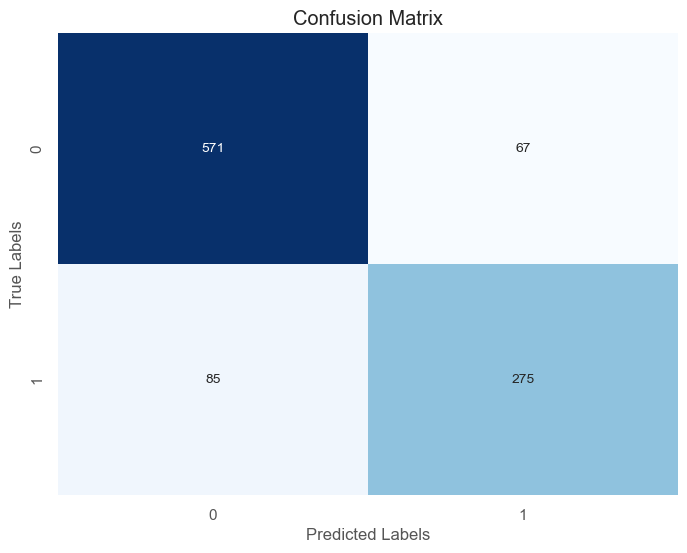

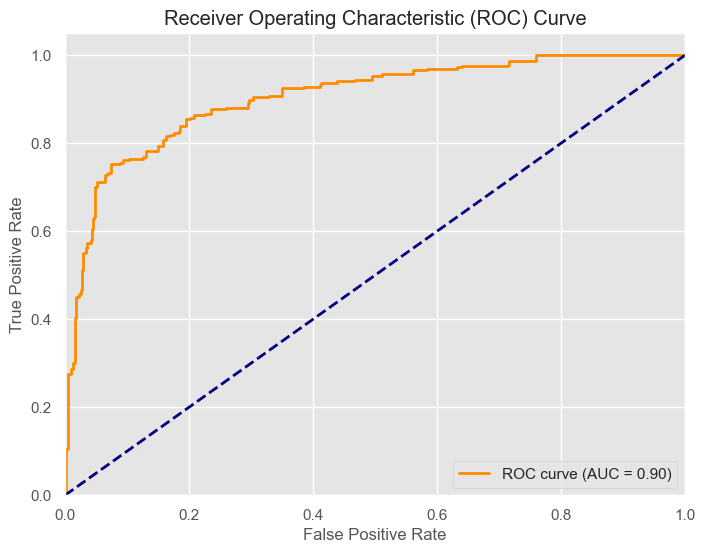

In [149]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Linear Discriminant Analysis model
lda = LinearDiscriminantAnalysis()

# Set up the hyperparameter grid for tuning
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],  # Solvers to consider
    'shrinkage': [None, 'auto', 0.1, 0.5, 0.9]  # Shrinkage values (only for 'lsqr' and 'eigen')
}

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(lda, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV on the training data
grid_search.fit(X_train_scaled, y_train)

# Print the best hyperparameters found by GridSearchCV
print("Best Parameters:", grid_search.best_params_)

# Train the LDA model with the best parameters
best_lda_model = grid_search.best_estimator_
best_lda_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = best_lda_model.predict(X_test_scaled)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"LDA Model Accuracy: {accuracy * 100:.2f}%")

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# ROC Curve and AUC score
y_pred_prob = best_lda_model.predict_proba(X_test_scaled)[:, 1]  # Get probabilities for the positive class

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # Calculate False Positive Rate and True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate AUC score

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random chance
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [151]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Apply scaling to the entire dataset

# Initialize the Linear Discriminant Analysis model
lda = LinearDiscriminantAnalysis()

# Perform cross-validation (using 5-fold cross-validation as an example)
cv_scores = cross_val_score(lda, X_scaled, y, cv=5, scoring='accuracy', n_jobs=-1)

# Print the cross-validation scores
print("Cross-Validation Scores:", cv_scores)
print(f"Mean Cross-Validation Score: {cv_scores.mean() * 100:.2f}%")



Cross-Validation Scores: [0.86573146 0.8496994  0.85771543 0.86172345 0.84168337]
Mean Cross-Validation Score: 85.53%


**Gradient Boosting**

Gradient Boosting Model Accuracy: 86.87%
Confusion Matrix:
 [[628  10]
 [121 239]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.98      0.91       638
           1       0.96      0.66      0.78       360

    accuracy                           0.87       998
   macro avg       0.90      0.82      0.85       998
weighted avg       0.88      0.87      0.86       998



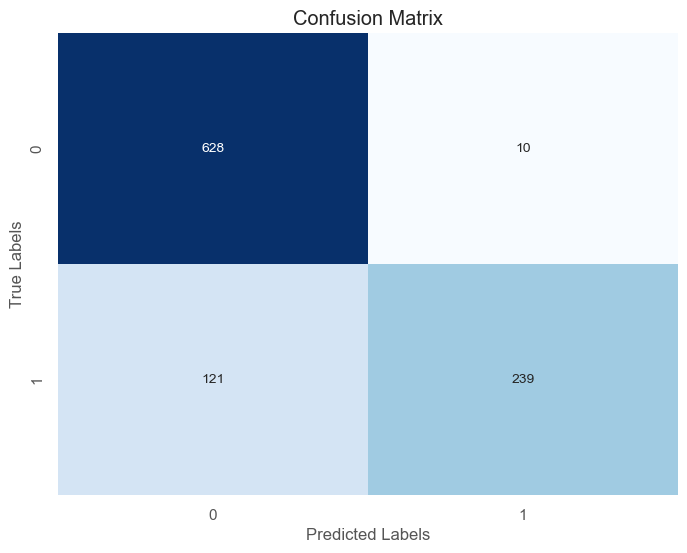

Cross-Validation Accuracy Scores: [0.87484355 0.85607009 0.88721805 0.88972431 0.86090226]
Mean Cross-Validation Accuracy: 87.38%


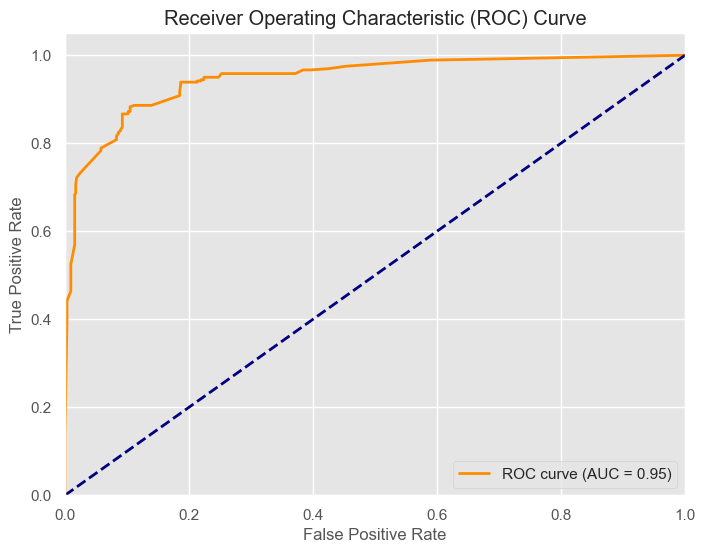

In [153]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gbc = GradientBoostingClassifier(
    n_estimators=50,         
    learning_rate=0.01,   
    max_depth=3,             
    random_state=42
)

# Train the model on the training data
gbc.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = gbc.predict(X_test_scaled)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting Model Accuracy: {accuracy * 100:.2f}%")

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Perform 5-fold cross-validation
cv_scores = cross_val_score(gbc, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Cross-Validation Accuracy: {:.2f}%".format(cv_scores.mean() * 100))

# ROC Curve and AUC score
y_pred_prob = gbc.predict_proba(X_test_scaled)[:, 1]  # Get probabilities for the positive class

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # Calculate False Positive Rate and True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate AUC score

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random chance
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



**AdaBoost**

Cross-Validation Accuracy Scores: [0.92866083 0.91864831 0.93233083 0.9085213  0.9085213 ]
Mean Cross-Validation Accuracy: 91.93%
AdaBoost Model Accuracy: 89.78%
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92       638
           1       0.88      0.83      0.85       360

    accuracy                           0.90       998
   macro avg       0.89      0.88      0.89       998
weighted avg       0.90      0.90      0.90       998



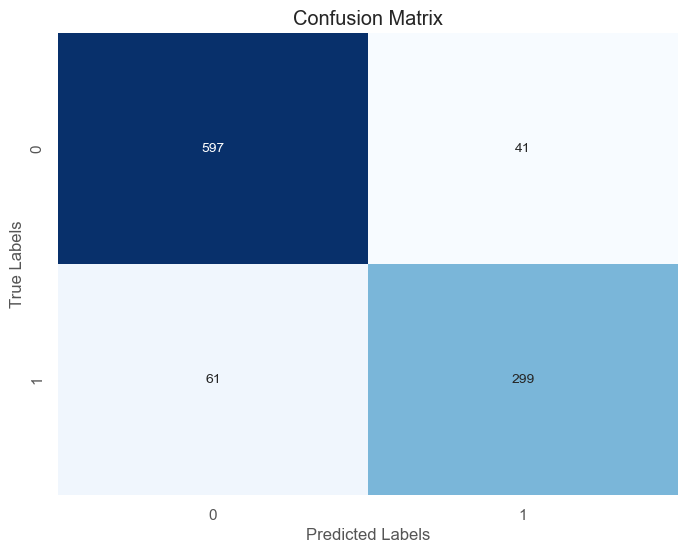

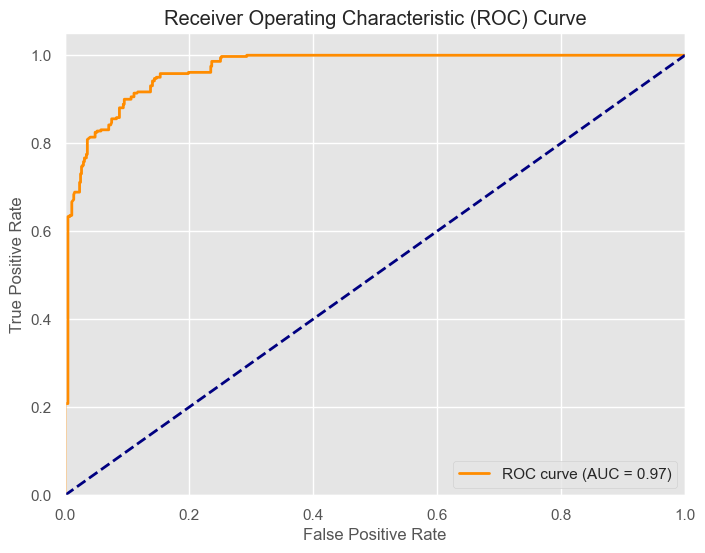

In [155]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the AdaBoost Classifier
ada_model = AdaBoostClassifier(n_estimators=50, random_state=0)

# Perform 5-fold cross-validation on the training set
cv_scores = cross_val_score(ada_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

# Print cross-validation scores and mean accuracy
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Cross-Validation Accuracy: {:.2f}%".format(cv_scores.mean() * 100))

# Train the AdaBoost model
ada_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = ada_model.predict(X_test_scaled)

# Evaluate the model's performance
accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"AdaBoost Model Accuracy: {accuracy * 100:.2f}%")

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, output_dict=True)

print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# ROC Curve and AUC score
y_pred_prob = ada_model.predict_proba(X_test_scaled)[:, 1]  # Get probabilities for the positive class

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # Calculate False Positive Rate and True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate AUC score

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random chance
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


**CNN**

In [157]:
from sklearn.model_selection import train_test_split

# Split the dataset into features (X) and target (y)
# Ensure that X and y are correctly defined
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the split datasets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Ensure the number of samples in X_train matches y_train
if X_train.shape[0] != y_train.shape[0]:
    print("Error: Mismatch in the number of samples between X_train and y_train.")
else:
    print("Data split is consistent.")


Shape of X: (4990, 18)
Shape of y: (4990,)
Shape of X_train: (3992, 18)
Shape of y_train: (3992,)
Shape of X_test: (998, 18)
Shape of y_test: (998,)
Data split is consistent.


Shape of X_train: (3992, 18)
Shape of X_test: (998, 18)
Shape of y_train: (3992,)
Shape of y_test: (998,)
Shape of X_train_reshaped: (3992, 18, 1)
Shape of X_test_reshaped: (998, 18, 1)
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4931 - loss: 0.9354 - val_accuracy: 0.5031 - val_loss: 0.6975 - learning_rate: 5.0000e-04
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5341 - loss: 0.7695 - val_accuracy: 0.5094 - val_loss: 0.7090 - learning_rate: 5.0000e-04
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5856 - loss: 0.6821 - val_accuracy: 0.5019 - val_loss: 0.7158 - learning_rate: 5.0000e-04
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6213 - loss: 0.6492 - val_accuracy: 0.5069 - val_loss: 0.7185 - learning_rate: 5.0000e-04
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6244 - loss: 0.6426 - val_accuracy: 0.4869 - val_loss: 0.7243 - learning_rate: 5.0000e-04
Epoch 6/50
100/100 ━━━━━━━━━━━━━━

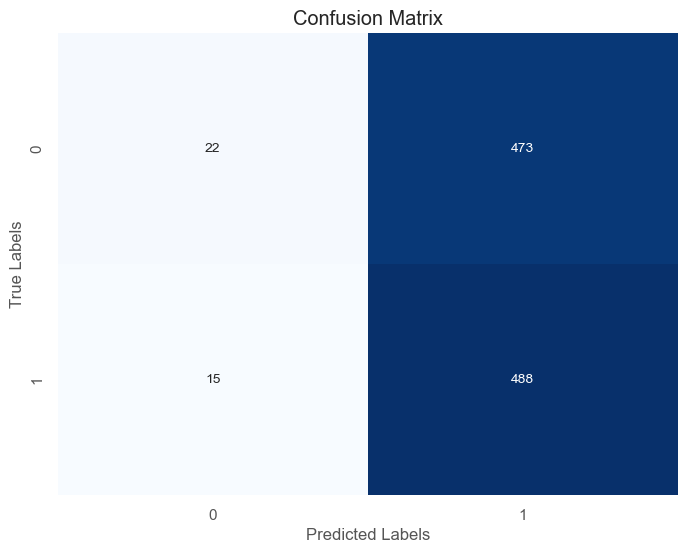

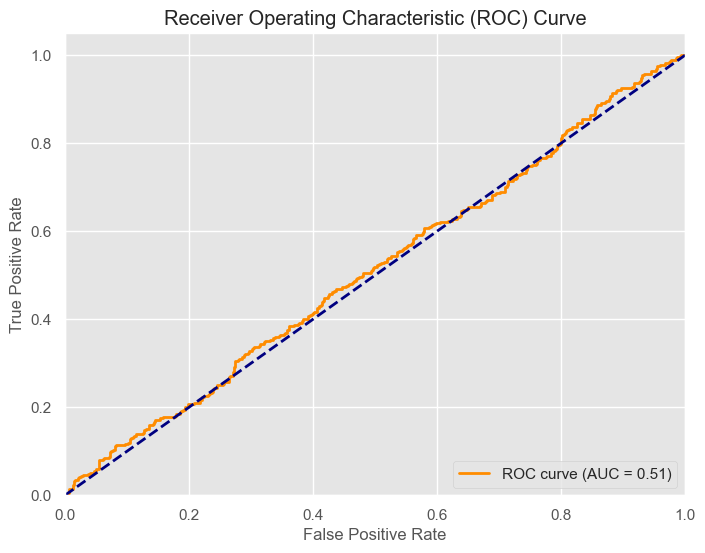

In [255]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape X_train and X_test for the CNN
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print(f"Shape of X_train_reshaped: {X_train_reshaped.shape}")
print(f"Shape of X_test_reshaped: {X_test_reshaped.shape}")

# Initialize the CNN model with a more complex architecture
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))  # Adjusted dropout rate
cnn_model.add(Dense(1, activation='sigmoid'))

# Compile the model with adjusted learning rate
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)

# Train the model
history = cnn_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping, reduce_lr])

# Evaluate the model
_, cnn_test_accuracy = cnn_model.evaluate(X_test_reshaped, y_test)
print(f"CNN Test Set Accuracy: {cnn_test_accuracy * 100:.2f}%")

# Make predictions
y_pred_prob = cnn_model.predict(X_test_reshaped).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate predictions
cnn_test_accuracy = accuracy_score(y_test, y_pred)
print(f"CNN Test Set Accuracy: {cnn_test_accuracy * 100:.2f}%")

# Confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# ROC Curve and AUC score
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [253]:
# Display the CNN model architecture
cnn_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 14, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,877 (687.02 KB)

 Trainable params: 58,497 (228.50 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 116,996 (457.02 KB)

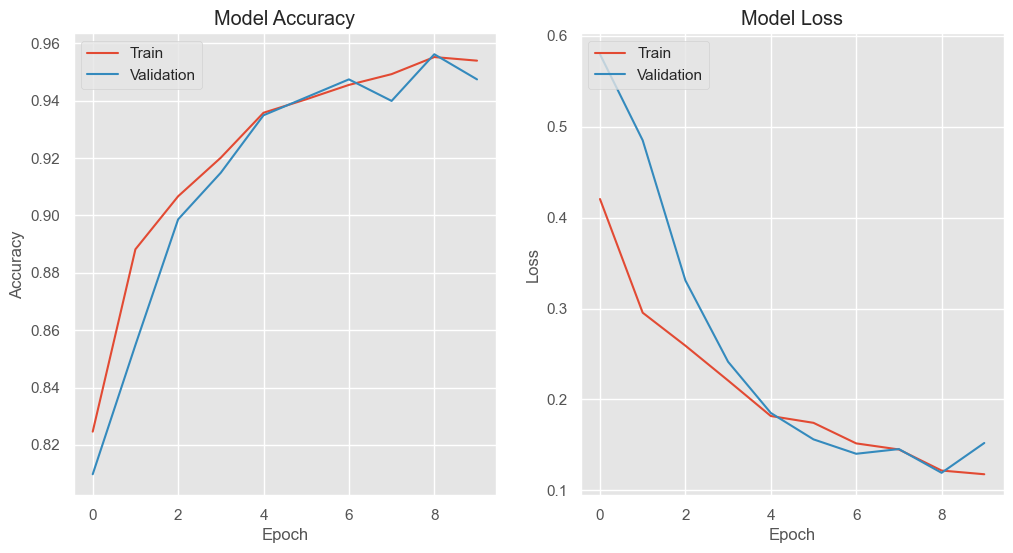

In [163]:
# Plot the training history
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


**ANN**

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6030 - loss: 0.6467 - val_accuracy: 0.7935 - val_loss: 0.4251
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8087 - loss: 0.4035 - val_accuracy: 0.8323 - val_loss: 0.3657
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8481 - loss: 0.3497 - val_accuracy: 0.8648 - val_loss: 0.3312
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8726 - loss: 0.3176 - val_accuracy: 0.8811 - val_loss: 0.3112
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8891 - loss: 0.2998 - val_accuracy: 0.8874 - val_loss: 0.2927
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8865 - loss: 0.2769 - val_accuracy: 0.8924 - val_loss: 0.2796
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8867 - loss: 0.2867 - val_accuracy: 0.8899 - val_loss: 0.2682
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8902 - loss: 0.2778 - val_accuracy: 0.

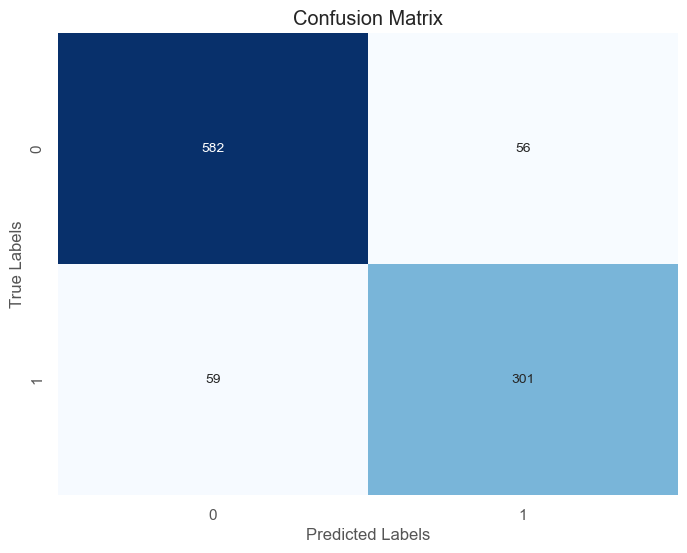

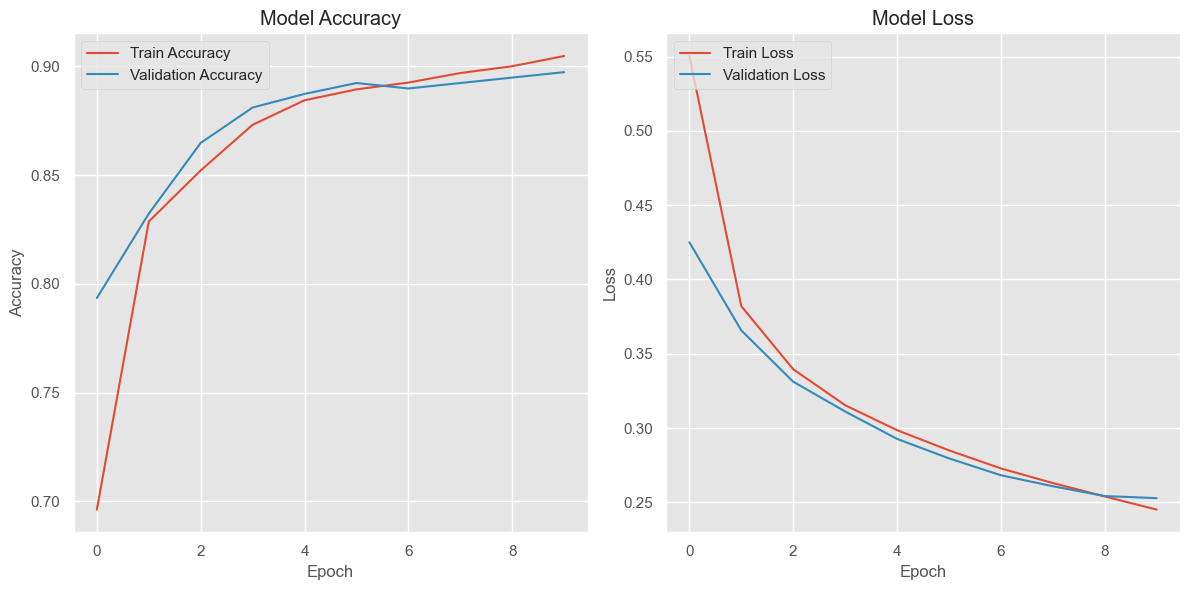

In [165]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Assuming X and y are already defined and preprocessed
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the ANN model
ann_model = Sequential()

# Add input layer and first hidden layer
ann_model.add(Dense(units=16, activation='relu', input_shape=(X_train.shape[1],)))

# Add second hidden layer
ann_model.add(Dense(units=16, activation='relu'))

# Add output layer
ann_model.add(Dense(units=1, activation='sigmoid'))  # Sigmoid activation for binary classification

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = ann_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on test data
y_pred_prob = ann_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary class predictions

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"ANN Model Accuracy: {accuracy * 100:.2f}%")

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step
AUC Score: 0.94


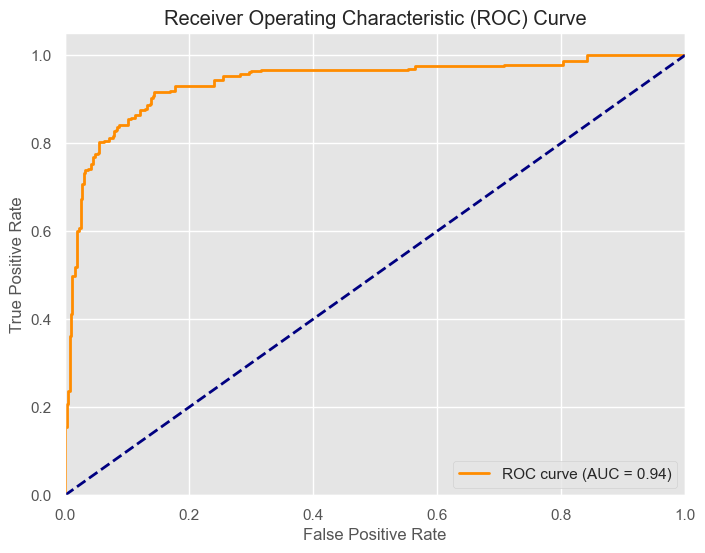

In [167]:
from sklearn.metrics import roc_curve, auc

# Get the predicted probabilities for the positive class
y_pred_prob = ann_model.predict(X_test).flatten()  # Flatten to ensure it's a 1D array

# Compute False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute the AUC (Area Under the Curve) score
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.2f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random chance
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


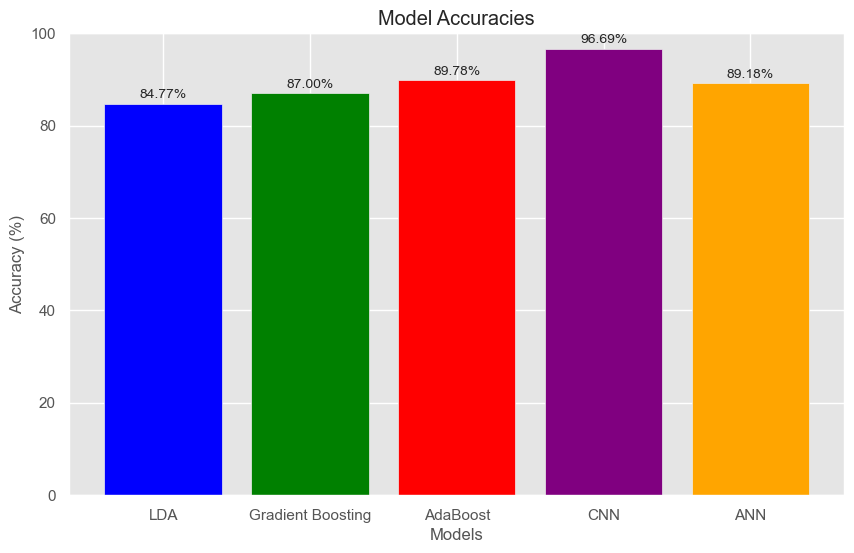

In [169]:
import matplotlib.pyplot as plt

# Model names and their accuracies
models = ['LDA', 'Gradient Boosting', 'AdaBoost', 'CNN', 'ANN']
accuracies = [84.77, 87, 89.78, 96.69, 89.18]

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple', 'orange'])

# Add labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracies')
plt.ylim([0, 100])  # Set y-axis limit from 0 to 100

# Add accuracy values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom')

# Show the plot
plt.show()


In [171]:
from tensorflow.keras.models import save_model

# Path where you want to save the CNN model
model_path = 'C:/Users/sneha/major project/model_save/cnn_model.h5'

# Save the trained CNN model
cnn_model.save(model_path)

print(f"CNN model saved successfully at {model_path}.")


CNN model saved successfully at C:/Users/sneha/major project/model_save/cnn_model.h5.


In [187]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 14, 32)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 64)          │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,933 (175.52 KB)

 Trainable params: 14,913 (58.25 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 29,828 (116.52 KB)

In [225]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler

# Define the path to the saved model
model_path = 'C:/Users/sneha/major project/model_save1/cnn_model.h5'

# Define the new sample data with both old and new features
new_data = pd.DataFrame({
    'Pregnancies': [9, 4, 13, 1, 7],
    'Glucose': [102.0, 171.0, 126.0, 93.0, 187.0],
    'BloodPressure': [76.0, 72.0, 90.0, 70.0, 50.0],
    'SkinThickness': [37.0, 32.0, 32.0, 31.0, 33.0],
    'Insulin': [168.0, 168.0, 168.0, 100.0, 270.0],
    'BMI': [32.9, 43.6, 43.4, 30.4, 33.9],
    'DiabetesPedigreeFunction': [0.665, 0.479, 0.583, 0.315, 0.826],
    'Age': [46, 26, 42, 23, 34],
    'NewBMI_Obesity 1': [1, 0, 0, 1, 1],
    'NewBMI_Obesity 2': [0, 0, 0, 0, 0],
    'NewBMI_Obesity 3': [0, 1, 1, 0, 0],
    'NewBMI_Overweight': [0, 0, 0, 1, 0],
    'NewBMI_Underweight': [0, 0, 0, 0, 1],
    'NewInsulinScore_Normal': [0, 0, 0, 0, 0],
    'NewGlucose_Low': [0, 0, 0, 1, 0],
    'NewGlucose_Normal': [0, 0, 1, 1, 0],
    'NewGlucose_Overweight': [0, 0, 0, 0, 0],
    'NewGlucose_Secret': [1, 1, 0, 0, 1]
})

# Assuming X_train is your original training data with 18 features
# Standardize the new data using the same scaler used for training
scaler = StandardScaler()
scaler.fit(X_train)  # Fit scaler on training data with 18 features

# Apply the scaler to the new data
new_data_scaled = scaler.transform(new_data)

# Reshape the new data to be compatible with CNN (1D CNN expects 3D input)
new_data_scaled = np.expand_dims(new_data_scaled, axis=2)

# Make predictions
predictions = cnn_model.predict(new_data_scaled)

# Convert predictions to binary class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(int)

# Print the predictions
for i, (prediction, pred_class) in enumerate(zip(predictions, predicted_classes)):
    print(f"Sample {i}: Probability of Diabetes = {prediction[0]:.4f}, Predicted Class = {pred_class[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Sample 0: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 1: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 2: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 3: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 4: Probability of Diabetes = 1.0000, Predicted Class = 1


In [233]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler

# Define the path to the saved model
model_path = 'C:/Users/sneha/major project/model_save1/cnn_model.h5'


# Define the new sample data with both old and new features
new_data = pd.DataFrame({
    'Pregnancies': [9, 4, 13, 1, 7, 5, 2, 10, 3, 8],
    'Glucose': [102.0, 171.0, 126.0, 93.0, 187.0, 150.0, 120.0, 200.0, 85.0, 160.0],
    'BloodPressure': [76.0, 72.0, 90.0, 70.0, 50.0, 80.0, 65.0, 95.0, 78.0, 70.0],
    'SkinThickness': [37.0, 32.0, 32.0, 31.0, 33.0, 35.0, 28.0, 40.0, 29.0, 36.0],
    'Insulin': [168.0, 168.0, 168.0, 100.0, 270.0, 150.0, 80.0, 200.0, 120.0, 190.0],
    'BMI': [32.9, 43.6, 43.4, 30.4, 33.9, 31.2, 28.5, 35.0, 29.8, 34.2],
    'DiabetesPedigreeFunction': [0.665, 0.479, 0.583, 0.315, 0.826, 0.520, 0.410, 0.620, 0.500, 0.670],
    'Age': [46, 26, 42, 23, 34, 29, 40, 50, 31, 38],
    'NewBMI_Obesity 1': [1, 0, 0, 1, 1, 0, 0, 1, 0, 1],
    'NewBMI_Obesity 2': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'NewBMI_Obesity 3': [0, 1, 1, 0, 0, 0, 0, 0, 0, 1],
    'NewBMI_Overweight': [0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    'NewBMI_Underweight': [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    'NewInsulinScore_Normal': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'NewGlucose_Low': [0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
    'NewGlucose_Normal': [0, 0, 1, 1, 0, 1, 0, 0, 1, 0],
    'NewGlucose_Overweight': [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    'NewGlucose_Secret': [1, 1, 0, 0, 1, 0, 1, 0, 0, 1]
})

# Assuming X_train is your original training data with 18 features
# Standardize the new data using the same scaler used for training
scaler = StandardScaler()
scaler.fit(X_train)  # Fit scaler on training data with 18 features

# Apply the scaler to the new data
new_data_scaled = scaler.transform(new_data)

# Reshape the new data to be compatible with CNN (1D CNN expects 3D input)
new_data_scaled = np.expand_dims(new_data_scaled, axis=2)

# Make predictions
predictions = cnn_model.predict(new_data_scaled)

# Convert predictions to binary class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(int)

# Print the predictions
for i, (prediction, pred_class) in enumerate(zip(predictions, predicted_classes)):
    print(f"Sample {i}: Probability of Diabetes = {prediction[0]:.4f}, Predicted Class = {pred_class[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Sample 0: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 1: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 2: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 3: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 4: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 5: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 6: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 7: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 8: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 9: Probability of Diabetes = 1.0000, Predicted Class = 1


In [237]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler

# Define the path to the saved model
model_path = 'C:/Users/sneha/major project/model_save1/cnn_model.h5'

# Define new sample data with values less indicative of diabetes
new_data = pd.DataFrame({
    'Pregnancies': [1, 2, 0, 3, 2],
    'Glucose': [85.0, 90.0, 75.0, 80.0, 70.0],
    'BloodPressure': [70.0, 60.0, 65.0, 75.0, 60.0],
    'SkinThickness': [20.0, 15.0, 10.0, 25.0, 20.0],
    'Insulin': [50.0, 60.0, 40.0, 55.0, 45.0],
    'BMI': [22.0, 20.0, 18.0, 24.0, 21.0],
    'DiabetesPedigreeFunction': [0.1, 0.2, 0.1, 0.2, 0.1],
    'Age': [22, 28, 30, 35, 40],
    'NewBMI_Obesity 1': [0, 0, 0, 0, 0],
    'NewBMI_Obesity 2': [0, 0, 0, 0, 0],
    'NewBMI_Obesity 3': [0, 0, 0, 0, 0],
    'NewBMI_Overweight': [0, 0, 0, 0, 0],
    'NewBMI_Underweight': [0, 0, 0, 0, 0],
    'NewInsulinScore_Normal': [1, 1, 1, 1, 1],
    'NewGlucose_Low': [1, 1, 1, 1, 1],
    'NewGlucose_Normal': [0, 0, 0, 0, 0],
    'NewGlucose_Overweight': [0, 0, 0, 0, 0],
    'NewGlucose_Secret': [0, 0, 0, 0, 0]
})

# Assuming X_train is your original training data with 18 features
# Standardize the new data using the same scaler used for training
scaler = StandardScaler()
scaler.fit(X_train)  # Fit scaler on training data with 18 features

# Apply the scaler to the new data
new_data_scaled = scaler.transform(new_data)

# Reshape the new data to be compatible with CNN (1D CNN expects 3D input)
new_data_scaled = np.expand_dims(new_data_scaled, axis=2)

# Make predictions
predictions = cnn_model.predict(new_data_scaled)

# Convert predictions to binary class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(int)

# Print the predictions
for i, (prediction, pred_class) in enumerate(zip(predictions, predicted_classes)):
    print(f"Sample {i}: Probability of Diabetes = {prediction[0]:.4f}, Predicted Class = {pred_class[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Sample 0: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 1: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 2: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 3: Probability of Diabetes = 1.0000, Predicted Class = 1
Sample 4: Probability of Diabetes = 1.0000, Predicted Class = 1
